# Triple Products

Cycle-test circuits for measuring the real parts of triple products `Re tr(σ_i σ_j σ_k)` for WH orbit states in `cirq_sic`.

In [1]:
from math import comb
import numpy as np
import cirq

from cirq_sic import *

In [4]:
d = 4
phi = load_sic_fiducial(d)
prepare_fiducial = ansatz_circuit(phi)

triples = [(0, 0), (1, 0), (2, 1)]
prepare_states = [
    (lambda qubits, a1=a1, a2=a2: wh_state(qubits, prepare_fiducial, a1, a2))
    for a1, a2 in triples
]

qubits = cirq.LineQubit.range(1 + 3 * int(np.log2(d)))
control_qubit = qubits[0]
n = int(np.log2(d))
register1 = qubits[1 : 1 + n]
register2 = qubits[1 + n : 1 + 2 * n]
register3 = qubits[1 + 2 * n : 1 + 3 * n]

circuit = triple_product_measurement_circuit(
    control_qubit,
    register1,
    register2,
    register3,
    prepare_states[0],
    prepare_states[1],
    prepare_states[2],
)

probabilities = exact_simulation(circuit)
measured_value = real_triple_product_from_probabilities(probabilities)

orbit_states = wh_frame(phi).T
orbit_projectors = [np.outer(psi, psi.conj()) for psi in orbit_states]
indices = [a1 * d + a2 for a1, a2 in triples]
expected_value = np.trace(
    orbit_projectors[indices[0]]
    @ orbit_projectors[indices[1]]
    @ orbit_projectors[indices[2]]
).real

print('Measured:', measured_value)
print('Expected:', expected_value)
print('Close:', np.allclose(measured_value, expected_value))

circuit

Measured: -0.029247046
Expected: -0.029247125175112895
Close: True


┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐
0: ───H────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────X────────@────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────H───M('result')───
                                                                                                                                                           │        │    │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │
1: ───Rz(1.63π)────Ry(0.566π)───Rz(0.133π)───@─────────────────@─────────────────@─────────────────@───H───@───────────────×───×─────────@────────H────────@────────X────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────┼───┼───────┼─────────────┼──────────┼───┼──────────┼───┼───────────┼───┼───┼────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────┼───┼───────┼─────────────┼──────────┼───┼──────────┼───┼───────────┼───┼───┼────┼────────────────────────────
                                             │                 │                 │                 │       │               │   │         │                               │             │              │              │               │        │          │   │       │             │          │   │          │   │           │   │   │    │                      │             │              │              │               │        │          │   │       │             │          │   │          │   │           │   │   │    │
2: ───Ry(0.636π)─────────────────────────────X───Ry(-0.197π)───X───Rz(-0.338π)───X───Rz(-0.633π)───X───────@^0.5───H───────×───×───H─────@^-0.5──────────────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5──────────────────────
                                                                                                                                                                         │             │              │              │               │        │                      │             │              │              │               │        │                      │             │              │              │               │        │                      │             │              │              │               │        │
3: ───Rz(1.63π)────Ry(0.566π)───Rz(0.133π)───@─────────────────@─────────────────@─────────────────@───H───@───────────────×───Z───×──────────────@────────H─────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────────────────@─────H───T───X───T──────────X───T^-1───────X───T^-1────────X────────X──────────H───S^-1────┼─────────────┼─────

In [13]:
d = 4
phi = load_sic_fiducial(d)

task = CharacterizeWHTripleProductsTask(
    dataset_id='notebook',
    processor_id='willow_pink',
    run_type='clean',
    qubits=get_triple_product_qubits(d),
    n_shots=500,
    optimizer='cirq',
    d=d,
    fiducial=phi,
    fiducial_description='numerical_sic',
)

tensor_exact = exactify(task)['T']
orbit_states = wh_frame(phi).T
orbit_projectors = [np.outer(psi, psi.conj()) for psi in orbit_states]
tensor_numpy = np.array([
    [[np.trace(rho_i @ rho_j @ rho_k).real for rho_k in orbit_projectors]
     for rho_j in orbit_projectors]
    for rho_i in orbit_projectors
])

print('Unique circuits:', len(task.make_circuits()), 'of', comb(d**2 + 2, 3))
print('Tensor shape:', tensor_exact.shape)
print('Symmetric:', np.allclose(tensor_exact, np.transpose(tensor_exact, (1, 0, 2))))
print('Matches NumPy:', np.allclose(tensor_exact, tensor_numpy))

base_dir = 'tmp_triple_products'
run_sky_ground_task(task, base_dir=base_dir)
results = load_results(task, base_dir=base_dir)
tensor_empirical = np.array(results["processed_data"]["T"])

Unique circuits: 816 of 816
Tensor shape: (16, 16, 16)
Symmetric: True
Matches NumPy: False
2026-06-24 22:23:12 [INFO] notebook/d4/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-4_3-5_2-5_3-6_2-6_3: Task already exists. Skipping.


In [14]:
def _prepare_validity_map(T):
    n = T.shape[0]
    d = int(np.sqrt(n))
    P = np.sum(T, axis=0) / d**2
    Phi = np.linalg.pinv(P)
    return Phi


def _filter_valid_probabilities(probabilities, T, Phi=None):
    probabilities = np.asarray(probabilities, dtype=float)
    if Phi is None:
        Phi = _prepare_validity_map(T)
    L = np.einsum("ijk,kl->lij", T, Phi @ probabilities.T)
    valid = np.all(np.linalg.eigvals(L) >= 0, axis=1)
    return probabilities[valid]


def sample_valid_probabilities(N, T, *, seed=None):
    n = T.shape[0]
    rng = np.random.default_rng(seed)
    p = rng.dirichlet(np.ones(n), size=N)
    Phi = _prepare_validity_map(T)
    return _filter_valid_probabilities(p, T, Phi=Phi)


def sample_probabilities_near_centers(centers, n_per_center, *, concentration=200.0, seed=None, eps=1e-6):
    centers = np.asarray(centers, dtype=float)
    if centers.ndim != 2 or len(centers) == 0:
        raise ValueError('Expected non-empty centers with shape (n_centers, n_outcomes).')

    rng = np.random.default_rng(seed)
    centers = np.clip(centers, eps, None)
    centers = centers / centers.sum(axis=1, keepdims=True)

    samples = []
    for center in centers:
        alpha = concentration * center + eps
        samples.append(rng.dirichlet(alpha, size=n_per_center))
    return np.vstack(samples)


def _dedupe_rows(points, decimals=10):
    points = np.asarray(points, dtype=float)
    if len(points) == 0:
        return points.reshape(0, points.shape[-1] if points.ndim > 1 else 0)
    _, idx = np.unique(np.round(points, decimals=decimals), axis=0, return_index=True)
    return points[np.sort(idx)]


def collect_valid_probabilities_robust(
    target_count,
    T,
    *,
    guide_points=None,
    global_batch_size=50000,
    max_global_batches=40,
    guide_batch_size=32,
    samples_per_guide=64,
    guide_concentrations=(50.0, 150.0, 500.0, 1500.0),
    max_guide_rounds=40,
    seed=None,
    min_count=2,
):
    rng = np.random.default_rng(seed)
    Phi = _prepare_validity_map(T)
    collected = []

    def total_count():
        return sum(len(chunk) for chunk in collected)

    # Global simplex exploration first.
    for _ in range(max_global_batches):
        batch_seed = int(rng.integers(0, 2**32 - 1))
        batch = rng.dirichlet(np.ones(T.shape[0]), size=global_batch_size)
        valid_batch = _filter_valid_probabilities(batch, T, Phi=Phi)
        if len(valid_batch) > 0:
            collected.append(valid_batch)
        if total_count() >= target_count:
            break

    # Local exploration around guide points, if available.
    if guide_points is not None and len(guide_points) > 0 and total_count() < target_count:
        guide_points = np.asarray(guide_points, dtype=float)
        for concentration in guide_concentrations:
            for _ in range(max_guide_rounds):
                if total_count() >= target_count:
                    break
                n_guides = min(len(guide_points), guide_batch_size)
                guide_indices = rng.choice(len(guide_points), size=n_guides, replace=False)
                chosen_guides = guide_points[guide_indices]
                local_seed = int(rng.integers(0, 2**32 - 1))
                batch = sample_probabilities_near_centers(
                    chosen_guides,
                    samples_per_guide,
                    concentration=concentration,
                    seed=local_seed,
                )
                valid_batch = _filter_valid_probabilities(batch, T, Phi=Phi)
                if len(valid_batch) > 0:
                    collected.append(valid_batch)
            if total_count() >= target_count:
                break

    if total_count() < min_count:
        raise ValueError(
            'Too few valid probability vectors were found. '
            'Increase global_batch_size/max_global_batches or guide-based sampling parameters.'
        )

    valid_p = _dedupe_rows(np.vstack(collected))
    if len(valid_p) > target_count:
        indices = rng.choice(len(valid_p), size=target_count, replace=False)
        valid_p = valid_p[indices]
    return valid_p

## Projection Snapshots

In [15]:
from itertools import combinations
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull


PROJECTION_CONFIG = {
    'cache_path': Path('triple_products_fast_d4_cache.npz'),
    'refresh_cache': True,
    'target_count_exact': 10000,
    'target_count_empirical': 10000,
    'global_batch_size': 10000,
    'max_global_batches': 20,
    'guide_batch_size': 24,
    'samples_per_guide': 24,
    'guide_concentrations': (50.0, 150.0, 500.0),
    'max_guide_rounds': 20,
    'seed_exact': 1,
    'seed_empirical': 0,
    'plot_max_points_per_set': 600,
    'max_2d': 4,
    'max_3d': 4,
}


def simplex_center(n_outcomes):
    return np.ones(n_outcomes) / n_outcomes


def simplex_projection_basis(n_outcomes):
    if n_outcomes < 2:
        raise ValueError('Need at least two outcomes to define a simplex hyperplane.')

    raw_basis = np.zeros((n_outcomes, n_outcomes - 1), dtype=float)
    raw_basis[:-1, :] = np.eye(n_outcomes - 1)
    raw_basis[-1, :] = -1
    q, _ = np.linalg.qr(raw_basis)
    return q[:, : n_outcomes - 1]


def project_probability_vectors(probabilities, basis=None):
    probabilities = np.asarray(probabilities, dtype=float)
    if probabilities.ndim != 2:
        raise ValueError('Expected shape (n_points, n_outcomes).')
    n_outcomes = probabilities.shape[1]
    center = simplex_center(n_outcomes)
    if basis is None:
        basis = simplex_projection_basis(n_outcomes)
    return (probabilities - center) @ basis


def _dedupe_rows(points, decimals=10):
    points = np.asarray(points, dtype=float)
    if len(points) == 0:
        return points.reshape(0, points.shape[1])
    _, idx = np.unique(np.round(points, decimals=decimals), axis=0, return_index=True)
    return points[np.sort(idx)]


def collect_projection_points(config):
    cache_path = config['cache_path']
    if cache_path.exists() and not config['refresh_cache']:
        cache = np.load(cache_path)
        valid_p = cache['valid_p']
        valid_p_exact = cache['valid_p_exact']
        print(f'Loaded cached valid points from {cache_path}')
        return valid_p, valid_p_exact

    valid_p_exact = collect_valid_probabilities_robust(
        config['target_count_exact'],
        tensor_exact,
        global_batch_size=config['global_batch_size'],
        max_global_batches=config['max_global_batches'],
        seed=config['seed_exact'],
    )

    valid_p = collect_valid_probabilities_robust(
        config['target_count_empirical'],
        tensor_empirical,
        guide_points=valid_p_exact,
        global_batch_size=config['global_batch_size'],
        max_global_batches=config['max_global_batches'],
        guide_batch_size=config['guide_batch_size'],
        samples_per_guide=config['samples_per_guide'],
        guide_concentrations=config['guide_concentrations'],
        max_guide_rounds=config['max_guide_rounds'],
        seed=config['seed_empirical'],
    )

    np.savez(cache_path, valid_p=valid_p, valid_p_exact=valid_p_exact)
    print(f'Saved valid points to {cache_path}')
    return valid_p, valid_p_exact


def fit_shared_pca_basis(point_sets):
    stacked = np.vstack(point_sets)
    centered = stacked - stacked.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    return vh.T


def default_projection_specs(shared_basis, max_2d=4, max_3d=4):
    n_axes = shared_basis.shape[1]
    pair_candidates = list(combinations(range(min(n_axes, 5)), 2))
    triple_candidates = list(combinations(range(min(n_axes, 5)), 3))

    specs = []
    for axes in pair_candidates[:max_2d]:
        specs.append({'dim': 2, 'axes': axes, 'title': f'PC{axes[0]+1} vs PC{axes[1]+1}'})
    for axes in triple_candidates[:max_3d]:
        specs.append({'dim': 3, 'axes': axes, 'title': f'PC{axes[0]+1}, PC{axes[1]+1}, PC{axes[2]+1}'})
    return specs


def project_with_shared_basis(points, shared_basis, axes):
    return points @ shared_basis[:, axes]


def _subsample_points(points, max_points, seed=0):
    points = _dedupe_rows(points)
    if len(points) <= max_points:
        return points
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(points), size=max_points, replace=False)
    return points[idx]


def _set_equal_2d_axes(ax, points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    if radius == 0:
        radius = 1.0
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_aspect('equal')


def _set_equal_3d_axes(ax, points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    if radius == 0:
        radius = 1.0
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))


def _plot_projected_hulls_2d(ax, point_sets, colors, alphas):
    shown = []
    for points, color, alpha in zip(point_sets, colors, alphas):
        shown.append(points)
        ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.10, color=color)
        if len(points) >= 3:
            hull = ConvexHull(points, qhull_options='QJ')
            polygon = points[hull.vertices]
            ax.fill(polygon[:, 0], polygon[:, 1], color=color, alpha=alpha, edgecolor=color, linewidth=0.8)
            closed = np.vstack([polygon, polygon[0]])
            ax.plot(closed[:, 0], closed[:, 1], color=color, linewidth=0.8)
    _set_equal_2d_axes(ax, np.vstack(shown))


def _plot_projected_hulls_3d(ax, point_sets, colors, alphas):
    shown = []
    for points, color, alpha in zip(point_sets, colors, alphas):
        shown.append(points)
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=8, alpha=0.10, color=color)
        if len(points) >= 4:
            hull = ConvexHull(points, qhull_options='QJ')
            faces = [points[simplex] for simplex in hull.simplices]
            poly = Poly3DCollection(faces, facecolor=color, edgecolor=color, linewidth=0.2, alpha=alpha)
            ax.add_collection3d(poly)
    _set_equal_3d_axes(ax, np.vstack(shown))


def plot_projection_snapshots(
    valid_p,
    valid_p_exact,
    *,
    max_points_per_set=600,
    max_2d=4,
    max_3d=4,
    colors=('C0', 'C2'),
    labels=('experiment', 'theory'),
    alphas=(0.30, 0.14),
    figsize_scale=4.8,
    seed=0,
):
    intrinsic_valid = project_probability_vectors(valid_p)
    intrinsic_exact = project_probability_vectors(valid_p_exact)

    shared_basis = fit_shared_pca_basis([intrinsic_valid, intrinsic_exact])
    specs = default_projection_specs(shared_basis, max_2d=max_2d, max_3d=max_3d)

    n_panels = len(specs)
    ncols = 2
    nrows = ceil(n_panels / ncols)
    fig = plt.figure(figsize=(figsize_scale * ncols, figsize_scale * nrows))
    gs = GridSpec(nrows, ncols, figure=fig)

    for i, spec in enumerate(specs):
        row, col = divmod(i, ncols)
        dim = spec['dim']
        axes = tuple(spec['axes'])
        if dim == 3:
            ax = fig.add_subplot(gs[row, col], projection='3d')
        else:
            ax = fig.add_subplot(gs[row, col])

        proj_valid = _subsample_points(project_with_shared_basis(intrinsic_valid, shared_basis, axes), max_points_per_set, seed=seed)
        proj_exact = _subsample_points(project_with_shared_basis(intrinsic_exact, shared_basis, axes), max_points_per_set, seed=seed + 1)

        if dim == 2:
            _plot_projected_hulls_2d(ax, [proj_valid, proj_exact], colors, alphas)
            ax.set_xlabel(f'PC{axes[0]+1}')
            ax.set_ylabel(f'PC{axes[1]+1}')
        else:
            _plot_projected_hulls_3d(ax, [proj_valid, proj_exact], colors, alphas)
            ax.set_xlabel(f'PC{axes[0]+1}')
            ax.set_ylabel(f'PC{axes[1]+1}')
            ax.set_zlabel(f'PC{axes[2]+1}')
        ax.set_title(spec['title'])

    handles = [Patch(facecolor=c, edgecolor=c, alpha=a, label=l) for c, a, l in zip(colors, alphas, labels)]
    fig.legend(handles=handles, loc='upper right')
    fig.tight_layout()
    plt.show()


valid_p, valid_p_exact = collect_projection_points(PROJECTION_CONFIG)
print('valid_p shape:', valid_p.shape)
print('valid_p_exact shape:', valid_p_exact.shape)

Saved valid points to triple_products_fast_d4_cache.npz
valid_p shape: (29, 16)
valid_p_exact shape: (10, 16)


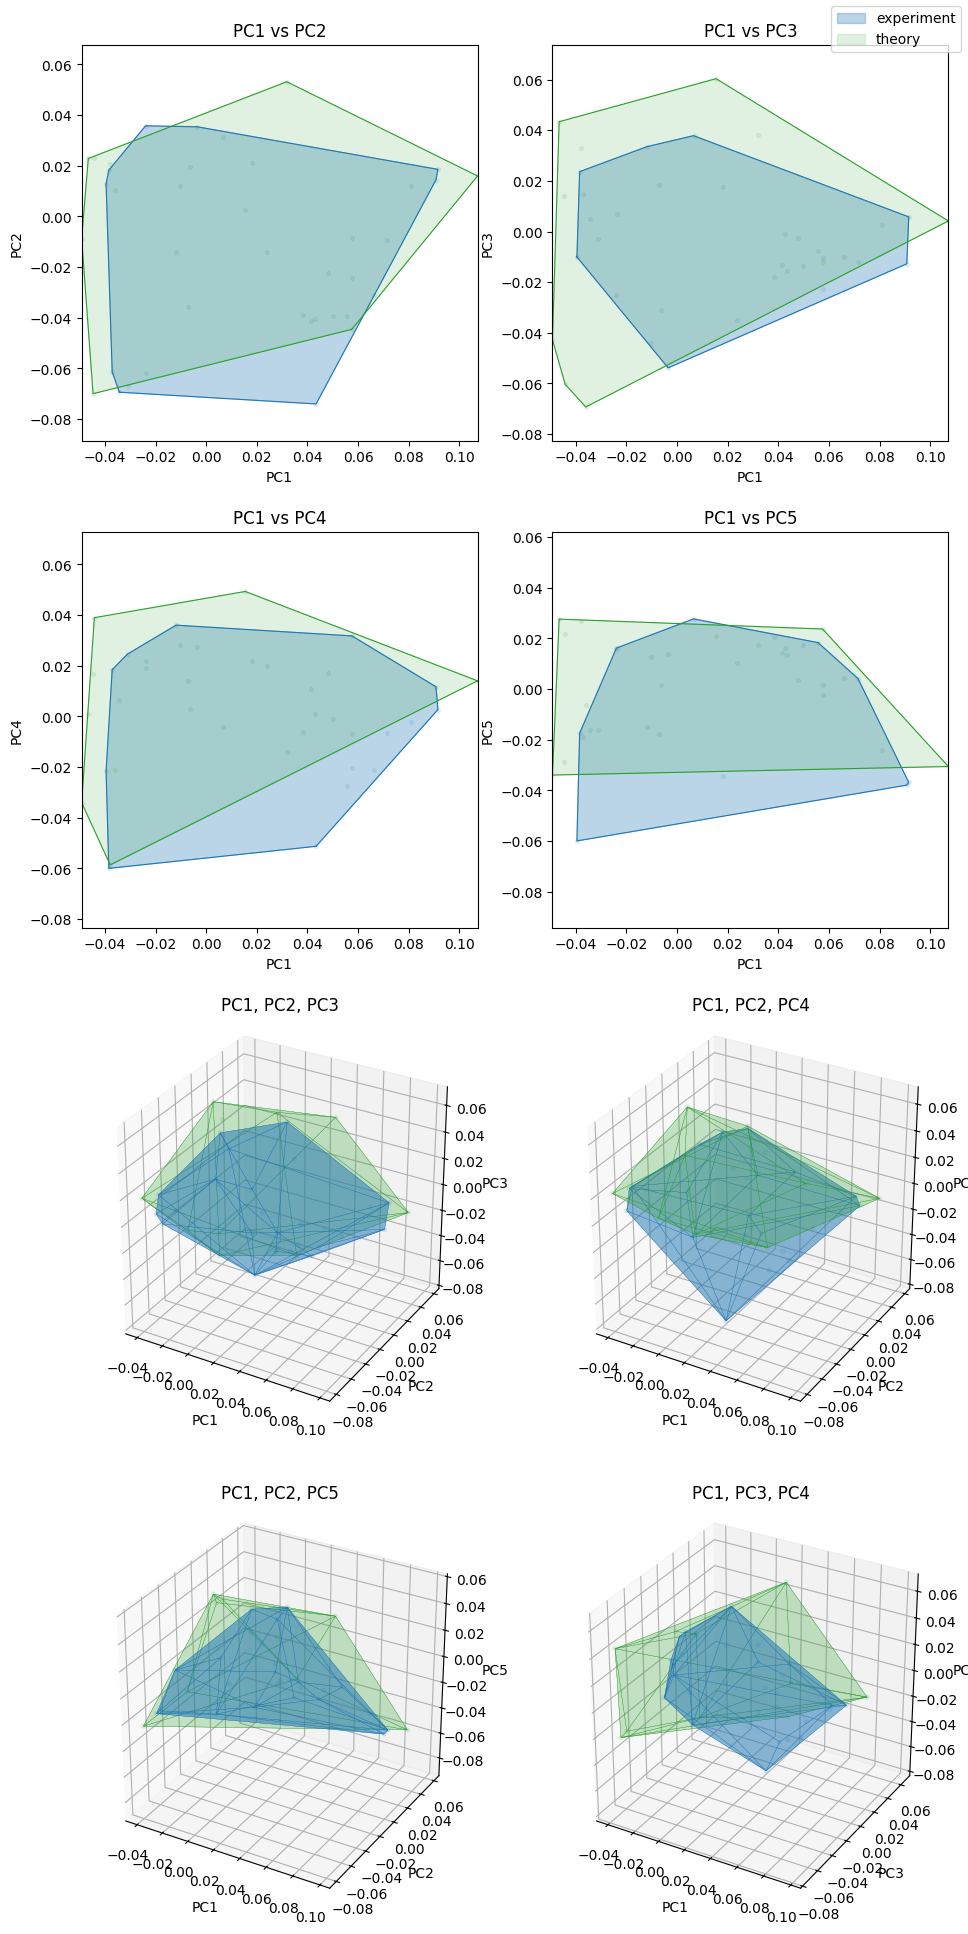

In [16]:
%matplotlib inline

plot_projection_snapshots(
    valid_p,
    valid_p_exact,
    max_points_per_set=PROJECTION_CONFIG['plot_max_points_per_set'],
    max_2d=PROJECTION_CONFIG['max_2d'],
    max_3d=PROJECTION_CONFIG['max_3d'],
    colors=('C0', 'C2'),
    labels=('experiment', 'theory'),
    alphas=(0.30, 0.14),
)